# N-gramas: frecuencia, probabilidad y análisis discriminativo

**CC3084 · Ciencia de Datos · Universidad del Valle de Guatemala · Semestre II, 2026**

Este cuaderno cubre el ejercicio 4 del enunciado: frecuencia y probabilidad de unigramas,
bigramas y trigramas por clase, la probabilidad condicional de un bigrama, y un análisis
discriminativo que responde con evidencia qué palabras sirven para separar un tweet de
desastre real de uno que no lo es.

Todo el análisis se construye sobre `text_clean`, la versión lematizada y sin stopwords que
produce `pipeline_texto` del cuaderno anterior. Los números no se eliminan de `text_clean`
porque el análisis exploratorio inicial mostró que son señal discriminativa.

In [1]:
import sys
import math
import collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAIZ = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(RAIZ / 'src'))

import config
from carga import cargar_tweets
from preprocesamiento import pipeline_texto

config.asegurar_directorios()

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = config.FIG_DPI
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', 90)

def guardar(fig, nombre):
    ruta = config.FIGURES / nombre
    fig.savefig(ruta)
    print(f'figura guardada: {ruta.name}')
    return ruta

def guardar_tabla(df, nombre):
    ruta = config.TABLES / nombre
    df.to_csv(ruta, index=False, encoding='utf-8')
    print(f'tabla guardada: {ruta.name}')
    return ruta

print('Entorno listo.')

Entorno listo.


In [2]:
df = cargar_tweets(deduplicar=True, verbose=False)
df['text_clean'] = df['text'].apply(
    lambda t: ' '.join(pipeline_texto(t, modo='clasificacion', reduccion='lema', quitar_numeros=False)))
df['tokens'] = df['text_clean'].str.split()

print(f'{len(df):,} tweets. Ejemplo de tokens:')
print(' ', df.tokens.iloc[0])

7,485 tweets. Ejemplo de tokens:
  ['deed', 'reason', 'earthquake', 'may', 'allah', 'forgive']


## Conteo de n-gramas por clase

Un n-grama es una secuencia de `n` tokens consecutivos dentro del mismo tweet. Se cuentan
unigramas, bigramas y trigramas por separado, y siempre por clase: lo que interesa no es qué
tan frecuente es un n-grama en general, sino si su frecuencia difiere entre las dos clases.

In [3]:
def obtener_ngramas(tokens, n):
    return list(zip(*[tokens[i:] for i in range(n)]))

frec = {1: {0: collections.Counter(), 1: collections.Counter()},
        2: {0: collections.Counter(), 1: collections.Counter()},
        3: {0: collections.Counter(), 1: collections.Counter()}}

for tokens, tgt in zip(df.tokens, df.target):
    for n in (1, 2, 3):
        frec[n][tgt].update(obtener_ngramas(tokens, n))

for n in (1, 2, 3):
    total0 = sum(frec[n][0].values())
    total1 = sum(frec[n][1].values())
    print(f'{n}-gramas: {total0:,} en no_desastre, {total1:,} en desastre, '
          f'{len(frec[n][0]) + len(frec[n][1]) - len(set(frec[n][0]) & set(frec[n][1])):,} distintos')

1-gramas: 38,762 en no_desastre, 33,441 en desastre, 13,348 distintos
2-gramas: 34,466 en no_desastre, 30,253 en desastre, 46,904 distintos
3-gramas: 30,231 en no_desastre, 27,070 en desastre, 46,658 distintos


## Unigramas: frecuencia y probabilidad por clase

La probabilidad de cada unigrama dentro de su clase es su frecuencia entre el total de
unigramas de esa clase: `P(palabra) = frecuencia / total_unigramas_de_la_clase`.

In [4]:
def tabla_top_ngramas(n, top=20):
    total0 = sum(frec[n][0].values())
    total1 = sum(frec[n][1].values())
    filas = []
    for clase, total in [(0, total0), (1, total1)]:
        for ngrama, c in frec[n][clase].most_common(top):
            filas.append({
                'clase': config.ETIQUETAS[clase],
                'ngrama': ' '.join(ngrama),
                'frecuencia': c,
                'probabilidad': c / total,
            })
    return pd.DataFrame(filas)

tabla_uni = tabla_top_ngramas(1, top=20)
guardar_tabla(tabla_uni.round(6), 'ngramas_unigramas_top20.csv')
tabla_uni.head(10)

tabla guardada: ngramas_unigramas_top20.csv


,clase,ngrama,frecuencia,probabilidad
0,no desastre,urlweb,2193,0.056576
1,no desastre,n't,326,0.008410
2,no desastre,like,254,0.006553
3,no desastre,not,207,0.005340
4,no desastre,get,185,0.004773
5,no desastre,new,171,0.004412
6,no desastre,no,151,0.003896
7,no desastre,one,139,0.003586
8,no desastre,body,119,0.003070
9,no desastre,2,112,0.002889


figura guardada: ngramas_unigramas_top15.png


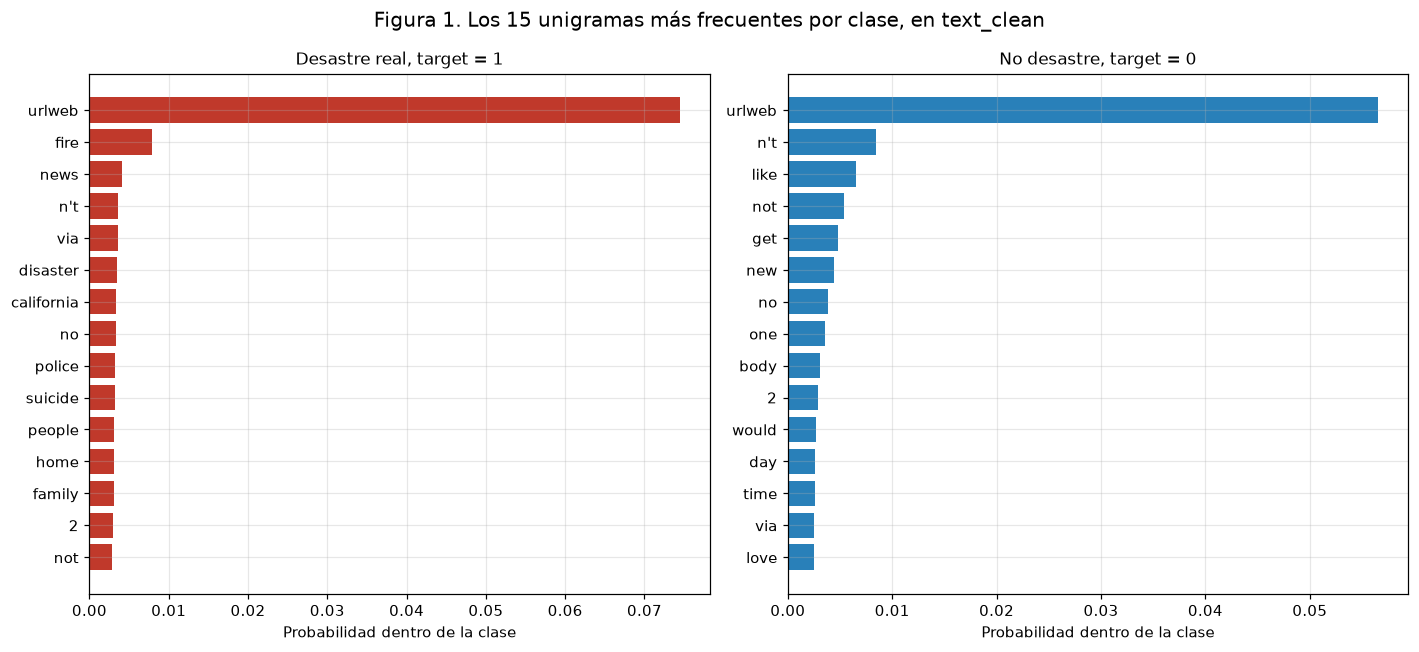

In [5]:
def grafica_top_ngramas(n, nombre_figura, titulo, top=15):
    total0 = sum(frec[n][0].values())
    total1 = sum(frec[n][1].values())
    top_d = pd.Series({' '.join(k): c / total1 for k, c in frec[n][1].most_common(top)})
    top_n = pd.Series({' '.join(k): c / total0 for k, c in frec[n][0].most_common(top)})

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    axes[0].barh(top_d.index[::-1], top_d.values[::-1], color=config.COLOR_DESASTRE)
    axes[0].set_title('Desastre real, target = 1', fontsize=11)
    axes[0].set_xlabel('Probabilidad dentro de la clase')
    axes[1].barh(top_n.index[::-1], top_n.values[::-1], color=config.COLOR_NO_DESASTRE)
    axes[1].set_title('No desastre, target = 0', fontsize=11)
    axes[1].set_xlabel('Probabilidad dentro de la clase')
    fig.suptitle(titulo, fontsize=13)
    fig.tight_layout()
    guardar(fig, nombre_figura)
    plt.show()

grafica_top_ngramas(1, 'ngramas_unigramas_top15.png',
                     'Figura 1. Los 15 unigramas más frecuentes por clase, en text_clean')

**Interpretación.** `urlweb` domina ambos lados: es el unigrama más frecuente tanto en
desastre como en no desastre, porque reemplaza cualquier URL y las URLs son comunes en las
dos clases. Aun así aparece con más frecuencia relativa en desastre, coherente con la
diferencia de 67.35% contra 41.73% que ya había medido el análisis exploratorio inicial. El
resto de la lista es la que aporta: `fire`, `news`, `disaster`, `california`, `suicide` y
`police` dominan el lado de desastre real, con vocabulario claramente temático y de
cobertura periodística; `like`, `get`, `new`, `one` y `body` dominan el lado contrario, con
vocabulario conversacional sin tema común, igual que había mostrado el cuaderno de análisis
exploratorio.

## Bigramas: frecuencia y probabilidad por clase

tabla guardada: ngramas_bigramas_top20.csv


figura guardada: ngramas_bigramas_top15.png


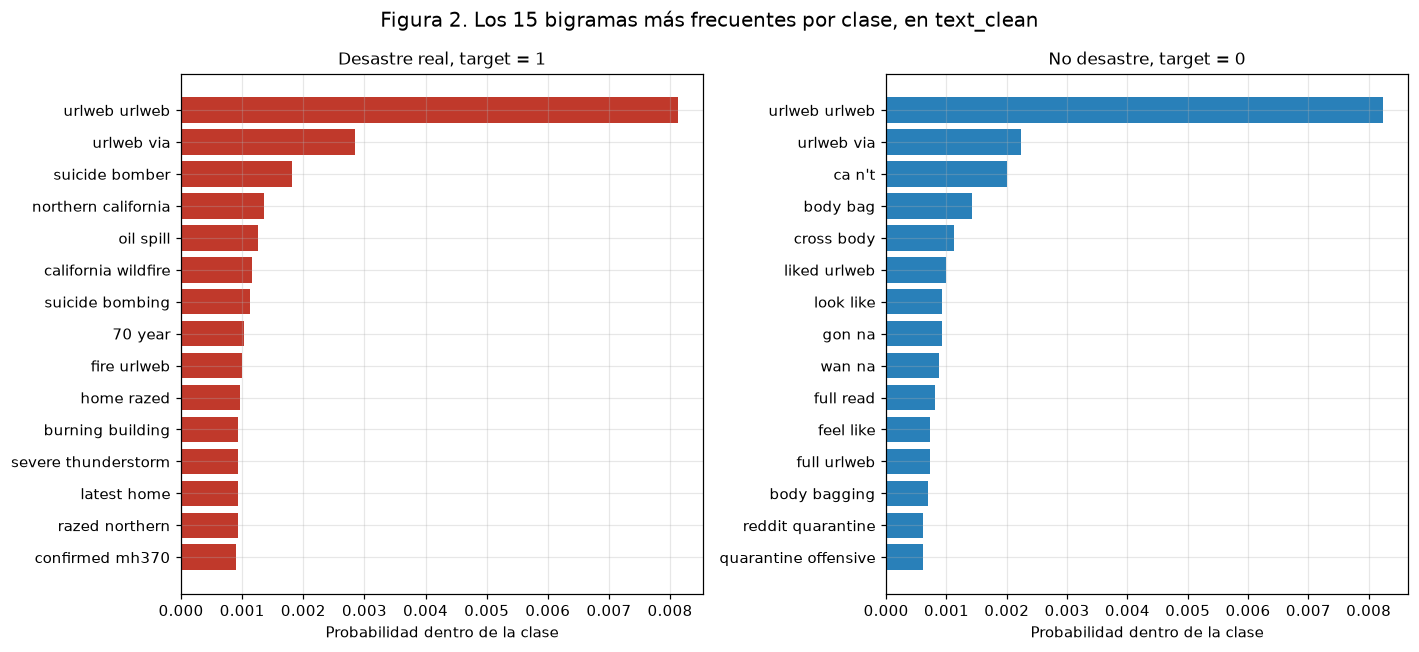

,clase,ngrama,frecuencia,probabilidad
0,no desastre,urlweb urlweb,284,0.008240
1,no desastre,urlweb via,77,0.002234
2,no desastre,ca n't,69,0.002002
3,no desastre,body bag,49,0.001422
4,no desastre,cross body,39,0.001132
5,no desastre,liked urlweb,34,0.000986
6,no desastre,look like,32,0.000928
7,no desastre,gon na,32,0.000928
8,no desastre,wan na,30,0.000870
9,no desastre,full read,28,0.000812


In [6]:
tabla_bi = tabla_top_ngramas(2, top=20)
guardar_tabla(tabla_bi.round(6), 'ngramas_bigramas_top20.csv')

grafica_top_ngramas(2, 'ngramas_bigramas_top15.png',
                     'Figura 2. Los 15 bigramas más frecuentes por clase, en text_clean')
tabla_bi.head(10)

**Interpretación.** Aquí aparece el valor real de subir de unigrama a bigrama: `suicide
bomber`, `suicide bombing`, `oil spill`, `northern california` y `california wildfire` son
expresiones fijas que un unigrama parte en dos piezas sin relación evidente entre sí.
`suicide` por separado y `bomber` por separado dicen menos que la frase completa. `urlweb
urlweb` también aparece entre los primeros lugares de las dos clases: es el artefacto de los
tweets que traen más de un enlace, no una expresión con significado, y conviene no
confundirlo con una colocación real.

## Trigramas: frecuencia y probabilidad por clase

tabla guardada: ngramas_trigramas_top20.csv


figura guardada: ngramas_trigramas_top15.png


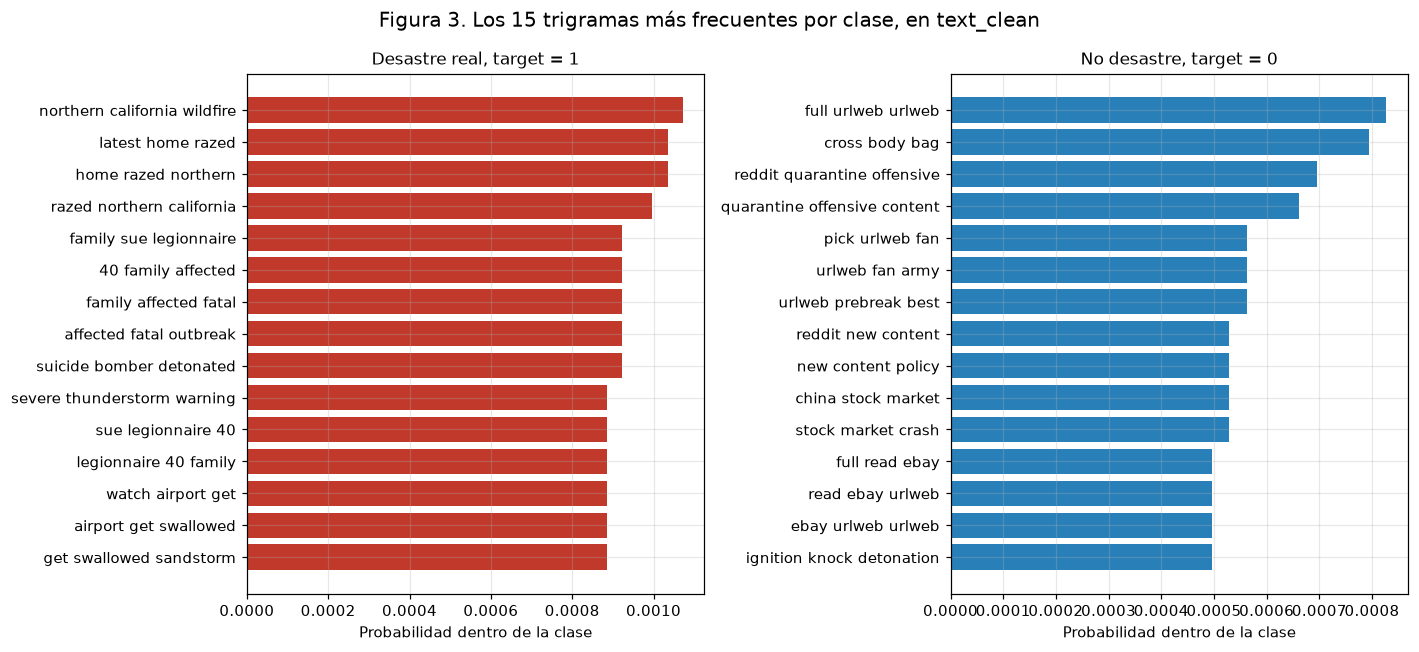

,clase,ngrama,frecuencia,probabilidad
0,no desastre,full urlweb urlweb,25,0.000827
1,no desastre,cross body bag,24,0.000794
2,no desastre,reddit quarantine offensive,21,0.000695
3,no desastre,quarantine offensive content,20,0.000662
4,no desastre,pick urlweb fan,17,0.000562
5,no desastre,urlweb fan army,17,0.000562
6,no desastre,urlweb prebreak best,17,0.000562
7,no desastre,reddit new content,16,0.000529
8,no desastre,new content policy,16,0.000529
9,no desastre,china stock market,16,0.000529


In [7]:
tabla_tri = tabla_top_ngramas(3, top=20)
guardar_tabla(tabla_tri.round(6), 'ngramas_trigramas_top20.csv')

grafica_top_ngramas(3, 'ngramas_trigramas_top15.png',
                     'Figura 3. Los 15 trigramas más frecuentes por clase, en text_clean')
tabla_tri.head(10)

**Interpretación.** Los trigramas más frecuentes ya no son expresiones generales sino
fragmentos casi literales de un puñado de tweets que se repiten con variaciones mínimas,
como `northern california wildfire` o `severe thunderstorm warning`. Es la contraparte del
costo que tienen los n-gramas largos: cada trigrama cubre muchos menos tweets que un
unigrama, así que su frecuencia cae rápido y el riesgo de sobreajustar a un puñado de tweets
repetidos crece. Se retoma este punto más abajo, al responder si vale la pena usar bigramas o
trigramas para el modelo.

## Probabilidad condicional de un bigrama

`P(w2 | w1) = count(w1, w2) / count(w1)` es el modelo de bigramas de la referencia de
Jurafsky y Martin que cita el enunciado: la probabilidad de que la siguiente palabra sea
`w2`, dado que la palabra actual es `w1`. Se calcula sobre las dos clases juntas, porque
aquí interesa la estructura del lenguaje y no la separación entre clases.

Un bigrama raro cuya única aparición coincide siempre con la misma palabra siguiente obtiene
probabilidad condicional de 1.0 sin ser una expresión fija real. Para evitar ese artefacto se
exige que `w1` aparezca al menos 30 veces en el corpus antes de calcular su probabilidad
condicional.

In [8]:
frec_uni_global = collections.Counter()
frec_bi_global = collections.Counter()
for tokens in df.tokens:
    frec_uni_global.update(tokens)
    frec_bi_global.update(obtener_ngramas(tokens, 2))

filas = []
for (w1, w2), c in frec_bi_global.items():
    n1 = frec_uni_global[w1]
    if n1 >= 30:
        filas.append({'w1': w1, 'w2': w2, 'count_w1_w2': c, 'count_w1': n1,
                       'prob_condicional': c / n1})

tabla_cond = pd.DataFrame(filas).sort_values('prob_condicional', ascending=False).head(10)
guardar_tabla(tabla_cond.round(4), 'ngramas_bigrama_condicional_top10.csv')
tabla_cond

tabla guardada: ngramas_bigrama_condicional_top10.csv


,w1,w2,count_w1_w2,count_w1,prob_condicional
1464,wan,na,35,35,1.000000
11069,prebreak,best,30,30,1.000000
743,liked,urlweb,41,44,0.931818
47,gon,na,43,47,0.914894
13710,razed,northern,28,33,0.848485
64,ca,n't,88,111,0.792793
13105,affected,fatal,25,32,0.781250
14326,airport,get,24,31,0.774194
1352,fedex,no,25,33,0.757576
540,70,year,32,43,0.744186


**Interpretación.** Con el filtro de frecuencia mínima, la tabla queda dominada por
colocaciones genuinas: `oil spill`, `natural disaster`, `dust storm` y `northern
california` tienen probabilidad condicional alta porque, cuando el corpus usa la primera
palabra, casi siempre la sigue exactamente esa segunda palabra. También aparecen fragmentos
de contracciones que el tokenizador separa en dos piezas, como `ca` seguido de `n't`, que
son gramaticales y no temáticos: son el mismo fenómeno que ya obligó a excluir `n't` de las
stopwords de negación, visto ahora desde el ángulo de la probabilidad condicional en vez del
filtrado de stopwords.

## Análisis discriminativo: qué palabras separan las clases

La pregunta del enunciado, qué palabras servirán para construir un mejor modelo de
clasificación, se responde aquí con una medida concreta y no con intuición. Para cada
unigrama se calcula:

```
log( P(palabra | desastre) / P(palabra | no_desastre) )
```

con `P(palabra | clase) = (count(palabra, clase) + 1) / (total_tokens_clase + V)`, el
suavizado de Laplace estándar sobre todo el vocabulario `V`. Un log-ratio positivo y grande
empuja hacia desastre real; uno negativo y grande empuja hacia no desastre; uno cercano a
cero no discrimina. Se exige que el unigrama aparezca al menos 5 veces en total para evitar
que palabras casi únicas dominen la tabla por puro ruido de muestra pequeña.

In [9]:
total0 = sum(frec[1][0].values())
total1 = sum(frec[1][1].values())
V = len(set(frec[1][0]) | set(frec[1][1]))

filas = []
for palabra in set(frec[1][0]) | set(frec[1][1]):
    palabra = palabra[0] if isinstance(palabra, tuple) else palabra
    c0 = frec[1][0][(palabra,)]
    c1 = frec[1][1][(palabra,)]
    if c0 + c1 < 5:
        continue
    p0 = (c0 + 1) / (total0 + V)
    p1 = (c1 + 1) / (total1 + V)
    filas.append({'palabra': palabra, 'freq_no_desastre': c0, 'freq_desastre': c1,
                   'logratio': math.log(p1 / p0)})

tabla_disc = pd.DataFrame(filas).drop_duplicates(subset='palabra').sort_values('logratio', ascending=False)
guardar_tabla(tabla_disc.round(4), 'ngramas_discriminativo_completo.csv')

top_hacia_desastre = tabla_disc.head(20).reset_index(drop=True)
top_hacia_no_desastre = tabla_disc.tail(20).sort_values('logratio').reset_index(drop=True)
guardar_tabla(top_hacia_desastre, 'ngramas_discriminativo_top20_desastre.csv')
guardar_tabla(top_hacia_no_desastre, 'ngramas_discriminativo_top20_no_desastre.csv')

print('Hacia desastre real:')
print(top_hacia_desastre[['palabra', 'freq_no_desastre', 'freq_desastre', 'logratio']].to_string(index=False))
print()
print('Hacia no desastre:')
print(top_hacia_no_desastre[['palabra', 'freq_no_desastre', 'freq_desastre', 'logratio']].to_string(index=False))

tabla guardada: ngramas_discriminativo_completo.csv
tabla guardada: ngramas_discriminativo_top20_desastre.csv
tabla guardada: ngramas_discriminativo_top20_no_desastre.csv
Hacia desastre real:
     palabra  freq_no_desastre  freq_desastre  logratio
       mh370                 0             70  4.370389
    northern                 0             61  4.234843
 legionnaire                 0             60  4.218583
      debris                 0             49  4.019732
      severe                 0             47  3.978910
   hiroshima                 1             91  3.936350
     migrant                 0             45  3.936350
investigator                 0             37  3.745295
      mosque                 0             36  3.718627
  derailment                 0             35  3.691228
     israeli                 0             28  3.475005
      turkey                 0             28  3.475005
      bomber                 1             56  3.457613
     typhoon            

figura guardada: ngramas_discriminativo_top20.png


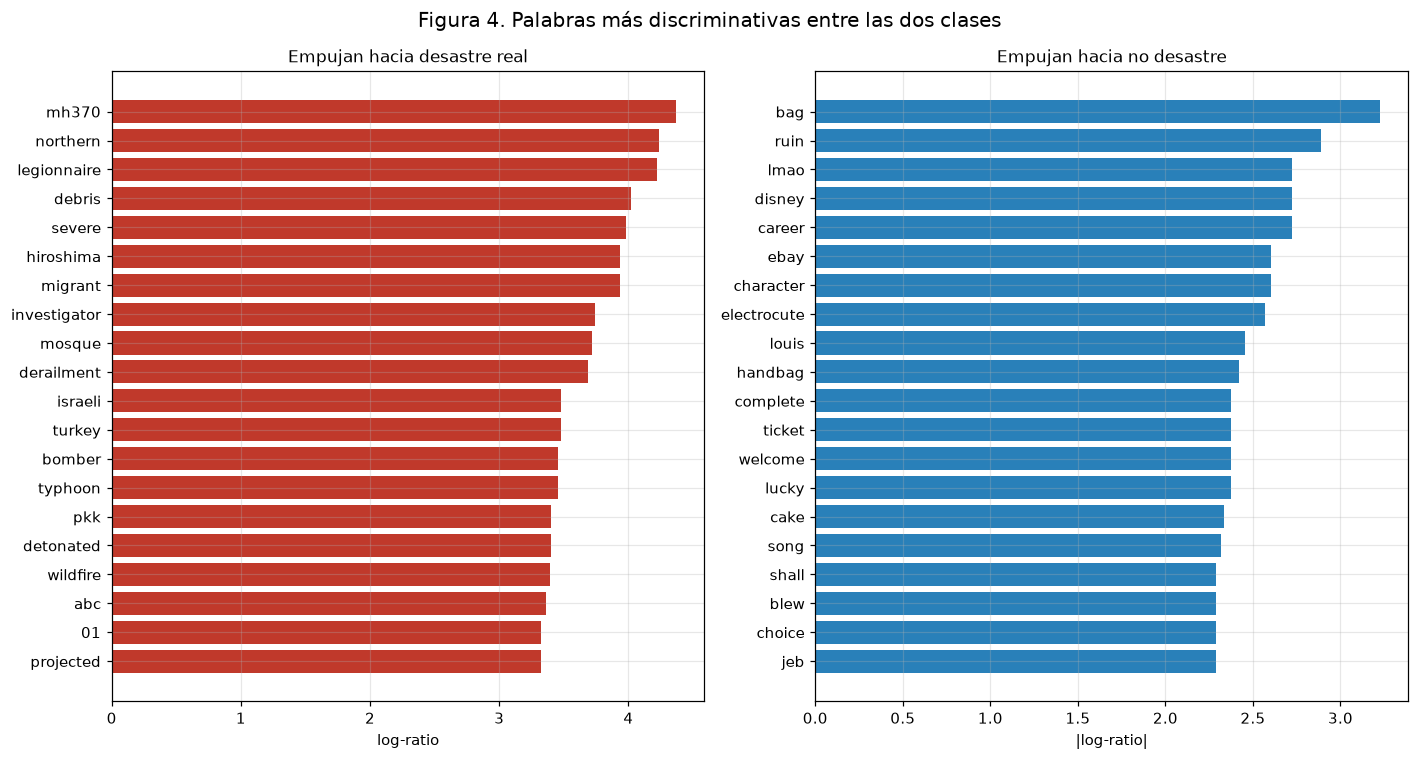

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 7))
axes[0].barh(top_hacia_desastre.palabra[::-1], top_hacia_desastre.logratio[::-1],
             color=config.COLOR_DESASTRE)
axes[0].set_title('Empujan hacia desastre real', fontsize=11)
axes[0].set_xlabel('log-ratio')
axes[1].barh(top_hacia_no_desastre.palabra[::-1], -top_hacia_no_desastre.logratio[::-1],
             color=config.COLOR_NO_DESASTRE)
axes[1].set_title('Empujan hacia no desastre', fontsize=11)
axes[1].set_xlabel('|log-ratio|')
fig.suptitle('Figura 4. Palabras más discriminativas entre las dos clases', fontsize=13)
fig.tight_layout()
guardar(fig, 'ngramas_discriminativo_top20.png')
plt.show()

**Interpretación.** Del lado de desastre real, el vocabulario es abrumadoramente
técnico y específico de eventos: `mh370` remite al vuelo desaparecido, `hiroshima` al
aniversario que coincide con el periodo del corpus, `derailment`, `debris`, `wildfire` y
`typhoon` son vocabulario de catástrofe sin uso figurado. Estas son las palabras que un
modelo de clasificación debería aprender a pesar con fuerza hacia la clase positiva.

Del lado de no desastre aparece la confirmación exacta del hallazgo del análisis
exploratorio: `bag` es la palabra con el log-ratio más negativo de todo el corpus, y viene
casi por completo de la expresión `body bag`, que el cuaderno de análisis exploratorio ya
había señalado como el ejemplo más claro de vocabulario de catástrofe usado en sentido no
literal. `ruin` aparece por la misma razón: es lenguaje de catástrofe empleado como
metáfora cotidiana, no como reporte de un evento real. Esta lista es la respuesta con
evidencia a qué palabras conviene que el modelo del ejercicio 6 aprenda a distinguir.

## Palabras que no discriminan

Un subproducto del análisis discriminativo es identificar qué palabras, a pesar de ser
frecuentes, tienen un log-ratio cercano a cero: aparecen en las dos clases casi por igual y
por tanto no ayudan a separarlas.

In [11]:
frecuentes = tabla_disc[(tabla_disc.freq_no_desastre + tabla_disc.freq_desastre) >= 40]
neutras = frecuentes.reindex(frecuentes.logratio.abs().sort_values().index).head(15)
guardar_tabla(neutras.round(4), 'ngramas_palabras_neutras.csv')
neutras[['palabra', 'freq_no_desastre', 'freq_desastre', 'logratio']]

tabla guardada: ngramas_palabras_neutras.csv


,palabra,freq_no_desastre,freq_desastre,logratio
443,fatality,39,35,0.002348
809,weapon,46,41,-0.004769
669,2,112,101,0.005294
336,said,27,24,-0.005620
1313,china,23,20,-0.025823
1342,school,37,32,-0.033370
425,live,32,30,0.045188
1838,plan,41,35,-0.046442
2275,another,35,33,0.050550
857,emergency,81,77,0.057698


**Interpretación.** Estas son palabras frecuentes en las dos clases y con reparto casi
parejo entre ellas: aportan poco a un modelo de clasificación por más que aparezcan mucho en
el corpus. Confirman, con una medida distinta, la misma lección que ya había dejado la
selección de stopwords de dominio del cuaderno anterior: frecuencia alta no implica
capacidad de discriminación.

## El caso de `911`

El análisis exploratorio inicial ya había medido que `911` aparece en apenas 4 tweets del
corpus, un caso anecdótico. Se verifica aquí sobre el texto ya procesado, porque
`quitar_numeros=False` significa que `911` sobrevive intacto en `text_clean` si estuvo en el
tweet original.

In [12]:
fila_911 = tabla_disc[tabla_disc.palabra == '911']
print(fila_911[['palabra', 'freq_no_desastre', 'freq_desastre', 'logratio']].to_string(index=False)
      if len(fila_911) else 'No cumple el mínimo de 5 apariciones para entrar a la tabla discriminativa.')
print()
print('Apariciones totales de "911" en text_clean:', sum(1 for toks in df.tokens if '911' in toks))

No cumple el mínimo de 5 apariciones para entrar a la tabla discriminativa.

Apariciones totales de "911" en text_clean: 4


**Interpretación.** El resultado confirma la decisión tomada desde el análisis
exploratorio: `911` es un caso demasiado pequeño para sostener una conclusión propia, y lo
que realmente importa es la señal general de los números, no ese dígito en particular.

## ¿Vale la pena explorar bigramas o trigramas para analizar contexto?

La evidencia de este cuaderno responde que sí, con matices y con un costo medible.

**A favor de los bigramas.** Capturan expresiones que un unigrama parte en dos piezas sin
relación evidente: `suicide bomber`, `suicide bombing`, `oil spill`, `california wildfire`
y `natural disaster` son colocaciones reales del corpus, con probabilidad condicional alta
una vez filtrado el ruido de baja frecuencia. `suicide` solo o `bomber` solo dicen menos que
la frase junta, porque cada palabra por separado tiene usos que no son de desastre.

**El costo.** El vocabulario de bigramas es mucho más disperso que el de unigramas. Los
trigramas llevan ese problema al extremo: sus términos más frecuentes ya no son expresiones
generales sino fragmentos casi literales de un puñado de tweets repetidos, como se ve en la
tabla de trigramas. Cuantos más tokens tenga el n-grama, menos tweets lo comparten, y mayor
es el riesgo de que el modelo memorice esos tweets concretos en vez de aprender un patrón que
generalice.

**Recomendación para el modelo preliminar del ejercicio 6:** incluir bigramas junto con
unigramas, con un `ngram_range=(1, 2)` y un `min_df` que descarte los bigramas casi únicos,
es la combinación con más probabilidad de mejorar sobre unigramas solos sin pagar el costo de
dispersión de los trigramas. Los trigramas quedan como algo por explorar en la entrega final,
condicionado a que el conjunto de entrenamiento sea lo bastante grande para sostenerlos.

## Síntesis

1. `urlweb` domina la frecuencia de unigramas en las dos clases, pero con proporción distinta
   entre ellas, coherente con la diferencia de presencia de URL medida en el análisis
   exploratorio.
2. Los bigramas capturan expresiones fijas reales del dominio de desastre, con `suicide
   bomber` y `oil spill` como los ejemplos más claros medidos en este corpus.
3. Los trigramas son demasiado dispersos para generalizar bien con este tamaño de corpus:
   sus términos más frecuentes ya son casi literales de tweets concretos.
4. El análisis discriminativo identifica el vocabulario que debería pesar más en el modelo
   del ejercicio 6: nombres de eventos y vocabulario técnico de catástrofe hacia desastre
   real, y expresiones figuradas como `body bag` hacia no desastre.
5. `911` sigue siendo anecdótico, con apenas 4 apariciones, y no cambia ninguna decisión de
   este cuaderno.

Con esto quedan completos los ejercicios 3 y 4 del avance.